In [1]:
# Imports
import os
import sys
import xarray as xr
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

# Import from wasp package
from wasp.io_ndbc import find_closest_time, load_ndbc_spectrum
from wasp.wave_params import calculate_wave_parameters
from wasp.partition import partition_spectrum
from wasp.plotting import plot_directional_spectrum
from wasp.utils import load_config, spectrum1d_from_2d

## 1. Configuration and Data Loading

Loading NDBC buoy spectral data from local file using wasp functions

In [2]:
# ============================================================================
# LOAD CONFIGURATION
# ============================================================================
CONFIG = load_config('./config.yaml')

# Partitioning parameters (from config.yaml)
MIN_ENERGY_THRESHOLD_FRACTION = CONFIG['partitioning']['ndbc']['min_energy_fraction']
MAX_PARTITIONS = CONFIG['partitioning']['ndbc']['max_partitions']
THRESHOLD_PERCENTILE = CONFIG['partitioning']['ndbc']['threshold_percentile']
MERGE_FACTOR = CONFIG['partitioning']['ndbc']['merge_factor']

# Plotting parameters (from config.yaml)
PLOT_PERIOD_MAX = CONFIG['plotting']['ndbc'].get('period_max', 25)

print(f"  threshold_percentile = {THRESHOLD_PERCENTILE}")
print(f"  merge_factor = {MERGE_FACTOR}")
print(f"  max_partitions = {MAX_PARTITIONS}")
print(f"  min_energy_fraction = {MIN_ENERGY_THRESHOLD_FRACTION}")

  threshold_percentile = 95.0
  merge_factor = 0.7
  max_partitions = 3
  min_energy_fraction = 0.01


## 2. Load NDBC Spectrum

NDBC provides:
- 1D spectral density in m²/Hz
- Fourier coefficients (r1, r2, α1, α2) for directional reconstruction



In [3]:
# ============================================================================
# LOAD NDBC SPECTRUM FROM LOCAL FILE
# ============================================================================

ndbc_file = '../data/41001w2020.nc' #This example file has only 1 day, from 01 to 02 December 2020, hourly.
station_id = 41001                  #At ndbc site: https://www.ndbc.noaa.gov/ its possible to find another station.
target_time = pd.to_datetime('2020-12-01 00:00:00')

# Open dataset
ds = xr.open_dataset(ndbc_file)

# Find closest time
itime, selected_time, time_diff_hours = find_closest_time(ds, target_time)

print(f"File: {os.path.basename(ndbc_file)}")
print(f"Station: {station_id}")
print(f"Target time: {target_time}")
print(f"Closest time: {selected_time}")
print(f"Time difference: {time_diff_hours:.2f} hours")

# Load 2D spectrum
spectrum_data = load_ndbc_spectrum(ds, itime, direction_resolution=15)

if spectrum_data is not None:
    E2d, freq, dirs, dirs_rad, lon, lat = spectrum_data
    print(f"\nLocation: {lon:.2f}°E, {lat:.2f}°N")
    print(f"Frequencies: {len(freq)} bins ({freq[0]:.4f} - {freq[-1]:.4f} Hz)")
    print(f"Directions: {len(dirs)} bins ({dirs[0]:.1f}° - {dirs[-1]:.1f}°)")
    print(f"E2d shape: {E2d.shape}")
else:
    print("Failed to load spectrum")

File: 41001w2020.nc
Station: 41001
Target time: 2020-12-01 00:00:00
Closest time: 2020-12-01 00:00:00
Time difference: 0.00 hours
  [DEBUG] NDBC m0=2.029405 m², Hs=5.70 m

Location: -72.32°E, 34.72°N
Frequencies: 47 bins (0.0200 - 0.4850 Hz)
Directions: 24 bins (0.0° - 345.0°)
E2d shape: (47, 24)


## 3. Calculate Integrated Wave Parameters

Calculate Hs, Tp, Dp from the 2D spectrum 

In [4]:
# Calculate Hs, Tp, Dp using trapezoidal integration
hs, tp, dp, m0, delf, ddir, i_peak, j_peak = calculate_wave_parameters(E2d, freq, dirs_rad)

# Display summary
print("\n" + "="*70)
print(" NDBC SPECTRUM INTEGRATED PARAMETERS")
print("="*70)
print(f"Station: {station_id}")
print(f"Location: {lon:.2f}°E, {lat:.2f}°N")
print(f"Time: {selected_time}")
print("─"*70)

print(f"\nCalculated (from 2D spectrum):")
print(f"   m0 = {m0:.6f} m²")
print(f"   Hs = {hs:.2f} m")
print(f"   Tp = {tp:.2f} s")
print(f"   Dp = {dp:.0f}°")
print("="*70)


 NDBC SPECTRUM INTEGRATED PARAMETERS
Station: 41001
Location: -72.32°E, 34.72°N
Time: 2020-12-01 00:00:00
──────────────────────────────────────────────────────────────────────

Calculated (from 2D spectrum):
   m0 = 2.029405 m²
   Hs = 5.70 m
   Tp = 10.00 s
   Dp = 165°


## 4. Spectral Partitioning

Apply spectral partitioning to identify wave systems 


In [5]:
# ============================================================================
# APPLY PARTITIONING (parameters from config.yaml)
# ============================================================================
results = partition_spectrum(
    E2d, freq, dirs_rad,
    threshold_mode='adaptive',
    threshold_percentile=THRESHOLD_PERCENTILE,
    merge_factor=MERGE_FACTOR,
    max_partitions=MAX_PARTITIONS
)

if results is None:
    print("No spectral peaks identified!")
else:
    min_energy_threshold = MIN_ENERGY_THRESHOLD_FRACTION * results['total_m0']
    n_peaks_initial = len(results['peaks'])

    # Count significant partitions
    n_partitions_final = sum(
        1 for i in range(1, len(results['Hs']))
        if results['energy'][i] > min_energy_threshold
    )

    print("\n" + "="*70)
    print(" SPECTRAL PARTITIONING - PROCESS SUMMARY")
    print("="*70)
    print(f"Spectral peaks initially identified: {n_peaks_initial}")
    print(f"After merging nearby systems: {n_partitions_final} partition(s)")
    print("="*70)

    print("\n" + "="*70)
    print(" PARTITIONING RESULTS")
    print("="*70)
    print(f"Number of significant partitions: {n_partitions_final}")
    print("─"*70)

    partition_count = 0
    for i in range(1, len(results['Hs'])):
        if results['energy'][i] > min_energy_threshold:
            partition_count += 1
            energy_pct = (results['energy'][i] / results['total_m0']) * 100
            print(f"\nPartition {partition_count}:")
            print(f"  Hs = {results['Hs'][i]:.2f} m")
            print(f"  Tp = {results['Tp'][i]:.2f} s")
            print(f"  Dp = {results['Dp'][i]:.0f}°")
            print(f"  Energy: {results['energy'][i]:.4f} m² ({energy_pct:.1f}%)")

    print("\n" + "─"*70)
    print(f"Integrated total:")
    print(f"  Hs = {results['total_Hs']:.2f} m")
    print(f"  Tp = {results['total_Tp']:.2f} s")
    print(f"  Dp = {results['total_Dp']:.0f}°")
    print("="*70)


Adaptive threshold: 5.54e+00 (95.0th percentile)
Identifying spectral peaks with threshold: 5.54e+00
Spectrum values: min=0.00e+00, max=5.20e+01, mean=8.35e-01
Identified 3 spectral peaks
Generating mask from ICOD...
  ICOD propagation converged after 3 iterations
Calculating distances between peaks...
Calculating peak spreading...
Checking for overlapping systems (merge_factor=0.7)...
Number of masks: 3
  Distance 9.0000e-04 <= Thresholds (3.8022e-03, 2.2690e-03)
  Merging systems 3 → 1
[DEBUG] Sum of partition energies: 2.029405
[DEBUG] Expected total: 2.029405
Total spectrum energy: 2.029405
Sum of partitioned energies: 2.029405

 SPECTRAL PARTITIONING - PROCESS SUMMARY
Spectral peaks initially identified: 3
After merging nearby systems: 2 partition(s)

 PARTITIONING RESULTS
Number of significant partitions: 2
──────────────────────────────────────────────────────────────────────

Partition 1:
  Hs = 5.55 m
  Tp = 10.00 s
  Dp = 165°
  Energy: 1.9241 m² (94.8%)

Partition 2:
  Hs = 

## 5. Plot Directional Spectrum

Polar plot showing energy distribution by frequency (period) and direction


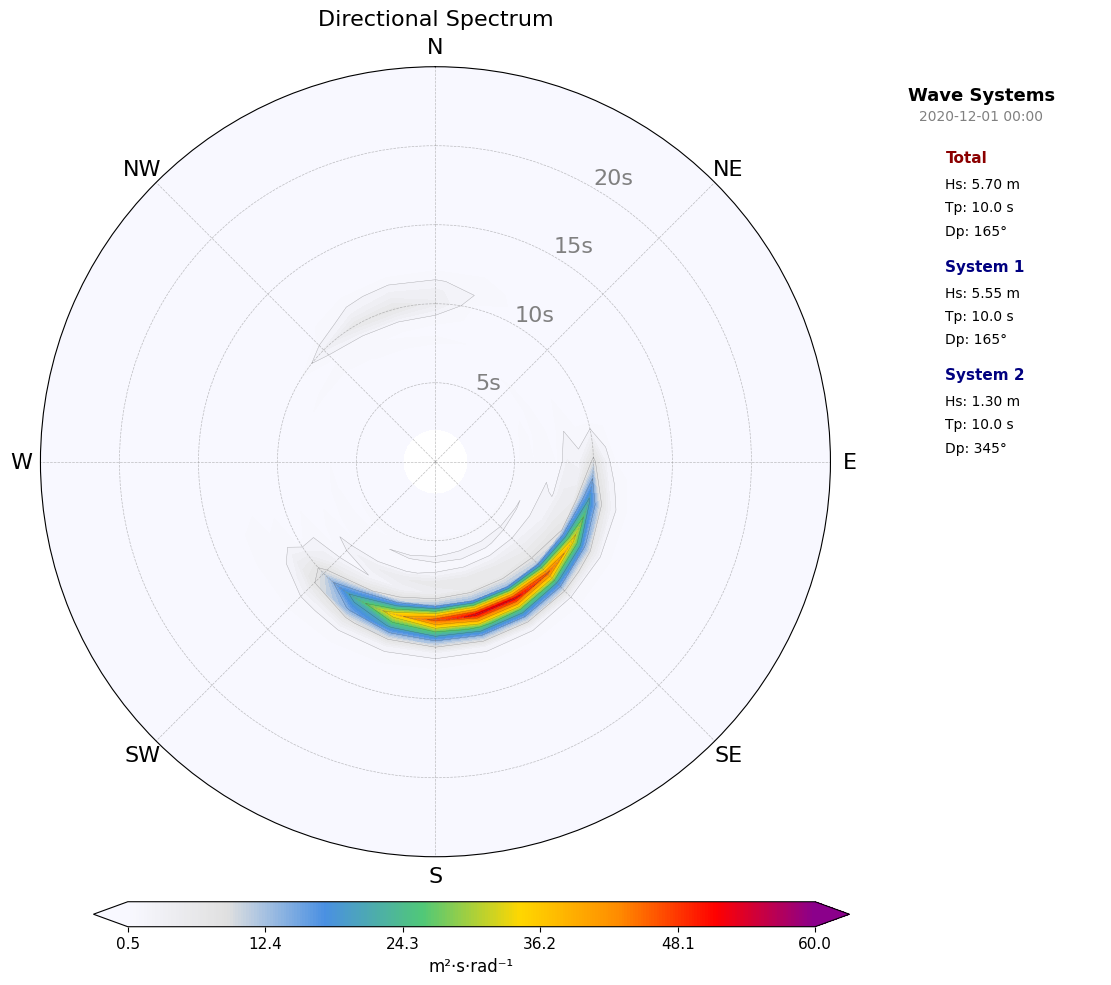

In [6]:

# ============================================================================
# PLOT: Total directional spectrum with identified wave systems
# ============================================================================

# Build partition list for the stats box
partitions_list = None
total_hs, total_tp, total_dp = None, None, None
if results is not None:
    min_e = MIN_ENERGY_THRESHOLD_FRACTION * results['total_m0']
    partitions_list = [
        {'Hs': results['Hs'][i], 'Tp': results['Tp'][i], 'Dp': results['Dp'][i]}
        for i in range(1, len(results['Hs']))
        if results['energy'][i] > min_e
    ]
    total_hs = results['total_Hs']
    total_tp = results['total_Tp']
    total_dp = results['total_Dp']

fig, ax = plot_directional_spectrum(
    E2d,
    freq,
    dirs,
    selected_time=selected_time,
    hs=total_hs,
    tp=total_tp,
    dp=total_dp,
    vmin=CONFIG['plotting']['ndbc'].get('spectrum_vmin'),
    vmax=CONFIG['plotting']['ndbc'].get('spectrum_vmax'),
    partitions=partitions_list,
)

plt.show()


## 6. 1D-Spectrum




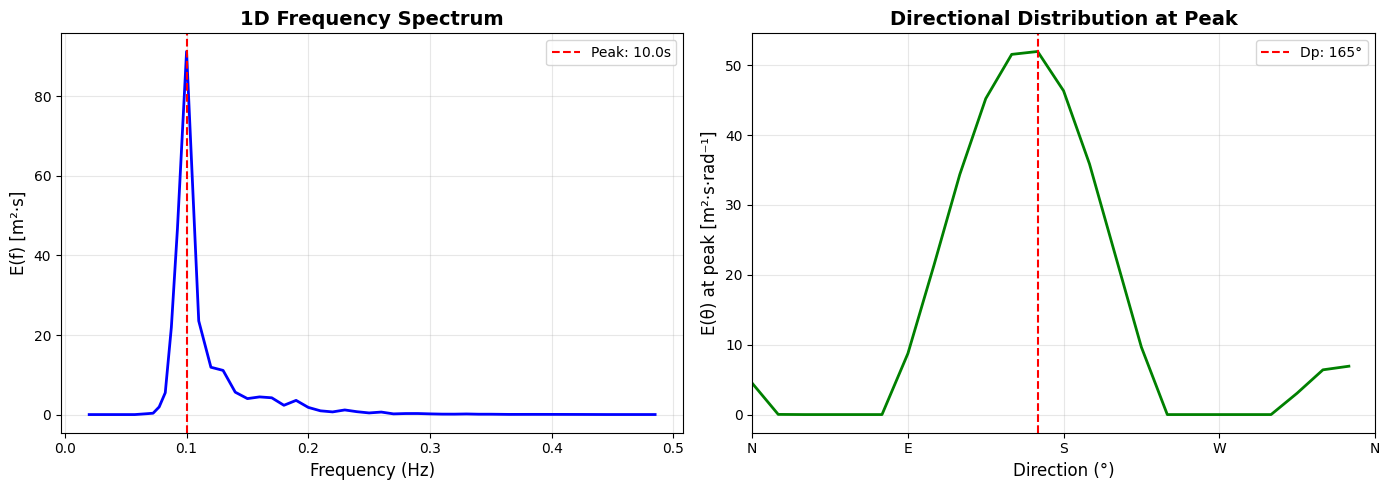

In [7]:
#Calculate integrated wave parameters (Hs, Tp, Dp, peak indices)
hs, tp, dp, m0, delf, ddir, i_peak, j_peak = calculate_wave_parameters(E2d, freq, dirs_rad)

# Calculate 1D spectrum
spec1d, ddir = spectrum1d_from_2d(E2d, dirs_rad)

# Plot 1D spectrum
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Frequency spectrum
ax1.plot(freq, spec1d, 'b-', linewidth=2)
ax1.axvline(freq[i_peak], color='r', linestyle='--', label=f'Peak: {1/freq[i_peak]:.1f}s')
ax1.set_xlabel('Frequency (Hz)', fontsize=12)
ax1.set_ylabel('E(f) [m²·s]', fontsize=12)
ax1.set_title('1D Frequency Spectrum', fontsize=14, weight='bold')
ax1.grid(True, alpha=0.3)
ax1.legend()

# Directional distribution at peak
ax2.plot(dirs, E2d[i_peak, :], 'g-', linewidth=2)
ax2.axvline(dp, color='r', linestyle='--', label=f'Dp: {dp:.0f}°')
ax2.set_xlabel('Direction (°)', fontsize=12)
ax2.set_ylabel('E(θ) at peak [m²·s·rad⁻¹]', fontsize=12)
ax2.set_title('Directional Distribution at Peak', fontsize=14, weight='bold')
ax2.set_xlim(0, 360)
ax2.set_xticks([0, 90, 180, 270, 360])
ax2.set_xticklabels(['N', 'E', 'S', 'W', 'N'])
ax2.grid(True, alpha=0.3)
ax2.legend()

plt.tight_layout()
plt.show()


# Saving results

In [8]:
# ============================================================================
# SAVE PARTITION RESULTS
# ============================================================================
output_dir = f'../data/partition-ndbc-{THRESHOLD_PERCENTILE}-{MERGE_FACTOR}'
os.makedirs(output_dir, exist_ok=True)

ref_id = str(station_id)
min_energy_threshold = MIN_ENERGY_THRESHOLD_FRACTION * results['total_m0']

moments = results['moments']
m0_total = moments['total'][0]
m1_total = moments['total'][1]
m2_total = moments['total'][2]

data = {
    'station_id': ref_id,
    'obs_time': selected_time,
    'longitude': float(lon),
    'latitude': float(lat),
    'source_file': os.path.basename(ndbc_file),
    
    # Total spectrum
    'total_energy': results['total_m0'],
    'total_Hs': results['total_Hs'],
    'total_Tp': results['total_Tp'],
    'total_Dp': results['total_Dp'],
    'total_m0': m0_total,
    'total_m1': m1_total,
    'total_m2': m2_total,
}

# Add partition data (up to 3 partitions)
partition_idx = 0
for i in range(1, len(results['Hs'])):
    if results['energy'][i] > min_energy_threshold:
        partition_idx += 1
        if partition_idx > 3:
            break
        data[f'P{partition_idx}_energy'] = results['energy'][i]
        data[f'P{partition_idx}_Hs'] = results['Hs'][i]
        data[f'P{partition_idx}_Tp'] = results['Tp'][i]
        data[f'P{partition_idx}_Dp'] = results['Dp'][i]
        data[f'P{partition_idx}_m0'] = moments['m0'][i]
        data[f'P{partition_idx}_m1'] = moments['m1'][i]
        data[f'P{partition_idx}_m2'] = moments['m2'][i]

# Fill remaining partitions with zeros
for p in range(partition_idx + 1, 4):
    for key in ['energy', 'Hs', 'Tp', 'Dp', 'm0', 'm1', 'm2']:
        data[f'P{p}_{key}'] = 0.0

# Save
date_str = selected_time.strftime('%Y%m%d-%H%M%S')
output_filename = f'ndbc_{ref_id}_{date_str}.csv'
output_path = os.path.join(output_dir, output_filename)

df_results = pd.DataFrame([data])
df_results.to_csv(output_path, index=False, float_format='%.6f')

print(f"Results saved to: {output_path}")
print(f"\nColumns: {list(df_results.columns)}")
print(f"\nPreview:")
df_results.T

Results saved to: ../data/partition-ndbc-95.0-0.7/ndbc_41001_20201201-000000.csv

Columns: ['station_id', 'obs_time', 'longitude', 'latitude', 'source_file', 'total_energy', 'total_Hs', 'total_Tp', 'total_Dp', 'total_m0', 'total_m1', 'total_m2', 'P1_energy', 'P1_Hs', 'P1_Tp', 'P1_Dp', 'P1_m0', 'P1_m1', 'P1_m2', 'P2_energy', 'P2_Hs', 'P2_Tp', 'P2_Dp', 'P2_m0', 'P2_m1', 'P2_m2', 'P3_energy', 'P3_Hs', 'P3_Tp', 'P3_Dp', 'P3_m0', 'P3_m1', 'P3_m2']

Preview:


,0
station_id,41001
obs_time,2020-12-01 00:00:00
longitude,-72.317001
latitude,34.723999
source_file,41001w2020.nc
total_energy,2.029405
total_Hs,5.698287
total_Tp,10.0
total_Dp,165.0
total_m0,2.202282
